In [1]:
import numpy as np
import pandas  as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
# Load dataset, using the 'error_bad_lines=False' argument to skip problematic lines
df = pd.read_csv("/content/weather_data.csv", on_bad_lines='skip', quoting=3)
# or use error_bad_lines=False for older versions of pandas
# df = pd.read_csv("/content/weather_data.csv", error_bad_lines=False)

In [2]:
df.head(5)

,id,city_name,city_id,latitude,longitude,dt_txt,temp,temp_min,temp_max,pressure,sea_level,grnd_level,humidity,main,description,clouds,wind_speed,wind_degree,region,state
0,103348,Amarawati,1263594.0,16.0,76.96,2020-01-29 08:30:00+05:30,23.45,23.45,23.45,1016.0,1016.0,971.0,59.0,Clouds,scattered clouds,44.0,2.83,312.0,"""West",NaN
1,"""",Maharashtra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,103349,Amarawati,1263594.0,16.0,76.96,2020-01-29 11:30:00+05:30,27.91,27.91,27.91,1015.0,1015.0,971.0,42.0,Clouds,few clouds,22.0,1.95,297.0,"""West",NaN
3,"""",Maharashtra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,103350,Amarawati,1263594.0,16.0,76.96,2020-01-29 14:30:00+05:30,31.14,31.14,31.14,1010.0,1010.0,967.0,34.0,Clear,clear sky,0.0,2.93,234.0,"""West",NaN


In [3]:
df.columns

Index(['id', 'city_name', 'city_id', 'latitude', 'longitude', 'dt_txt', 'temp',
       'temp_min', 'temp_max', 'pressure', 'sea_level', 'grnd_level',
       'humidity', 'main', 'description', 'clouds', 'wind_speed',
       'wind_degree', 'region', 'state'],
      dtype='object')

In [4]:
df.isnull().sum()

,0
id,0
city_name,0
city_id,145940
latitude,145940
longitude,145940
dt_txt,145940
temp,145941
temp_min,145941
temp_max,145941
pressure,145941


In [5]:
df.dropna(inplace=True)

In [6]:
# Drop only the columns that exist in the DataFrame
existing_columns = df.columns
columns_to_drop = ['id', 'city_id','state', 'pressure', 'sea_level', 'grnd_level', 'clouds','dt_txt','region', 'wind_degree', 'temp_min', 'temp_max']
valid_columns_to_drop = [col for col in columns_to_drop if col in existing_columns]

df = df.drop(columns=valid_columns_to_drop)

In [7]:
df.head()

,city_name,latitude,longitude,temp,humidity,main,description,wind_speed


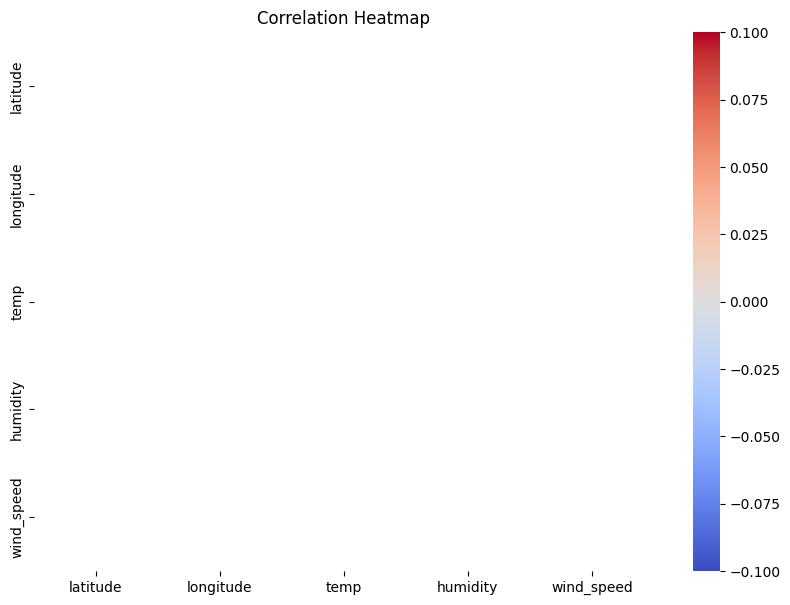

In [8]:
numerical_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(10, 7))
# Calculating the correlation on numerical features only
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [9]:
# Ensure that the columns you are dropping are actually present
columns_to_drop = ['id', 'city_id', 'pressure', 'sea_level', 'grnd_level', 'clouds','dt_txt','region', 'wind_degree', 'temp_min', 'temp_max']
existing_columns = df.columns
valid_columns_to_drop = [col for col in columns_to_drop if col in existing_columns]
df = df.drop(columns=valid_columns_to_drop, errors='ignore') # Use errors='ignore' to prevent errors if columns are not found

In [10]:
df = pd.read_csv("/content/weather_data.csv", on_bad_lines='skip', quoting=3)

df.dropna(subset=['wind_speed'], inplace=True)  # Remove rows with NaN in 'wind_speed'

X = df[['temp', 'humidity']]
y = df['wind_speed']
from sklearn.model_selection import train_test_split
# Train-test split
# Ensure that the DataFrame 'df' is not empty after data cleaning
if df.empty:
    print("Warning: DataFrame 'df' is empty. Check data loading and filtering steps.")
else:
    # Proceed with train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    # ... (Rest of your code) ...
    # Random Forest Regressor
    reg = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42)
    # Fit the model before making predictions.
    reg.fit(X_train, y_train)

    y_pred = reg.predict(X_test)

    # Evaluation
    print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
    print("R2 Score:", r2_score(y_test, y_pred))
#If the DataFrame is empty, the rest of the code dependent on X_train, X_test, y_train and y_test is skipped.

Mean Absolute Error: 1.0169481075840496
R2 Score: 0.1990568649353519


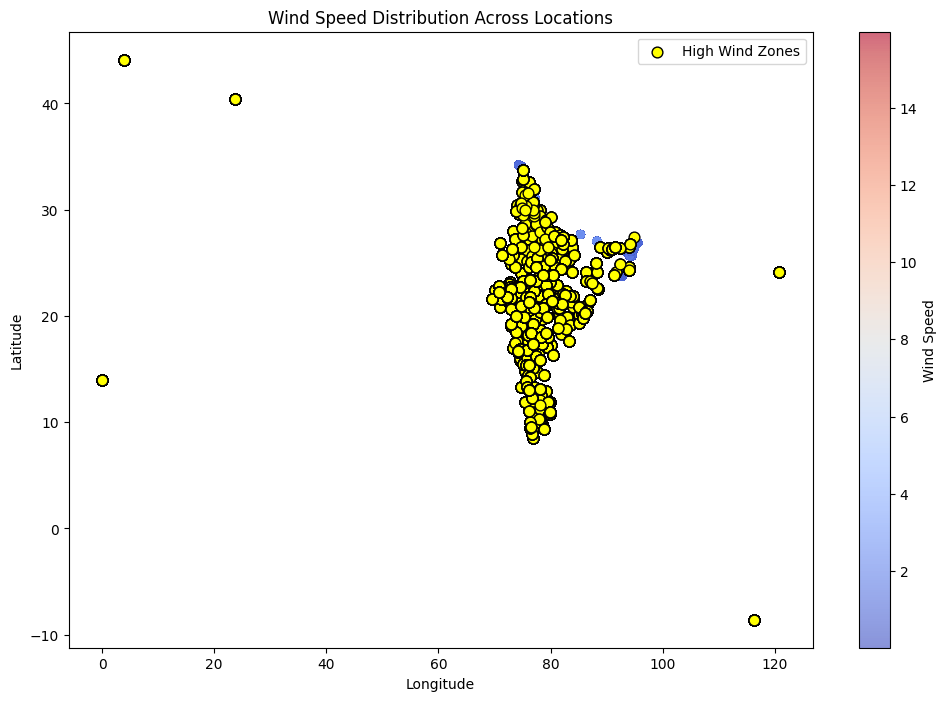

In [11]:
high_wind_threshold = df['wind_speed'].quantile(0.8)
high_wind_df = df[df['wind_speed'] >= high_wind_threshold]

# ✅ Scatter Plot of Latitude vs Longitude colored by Wind Speed
if 'longitude' in df.columns and 'latitude' in df.columns:  # Check for both columns
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(
        df['longitude'], df['latitude'],
        c=df['wind_speed'], cmap='coolwarm', s=30, alpha=0.6
    )

    # ✅ Highlight the high wind speed locations
    plt.scatter(
        high_wind_df['longitude'], high_wind_df['latitude'],
        color='yellow', edgecolor='black', s=60, label='High Wind Zones'
    )

    plt.colorbar(scatter, label='Wind Speed')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Wind Speed Distribution Across Locations')
    plt.legend()
    plt.show()
else:
    print("Error: 'longitude' or 'latitude' column not found in DataFrame.")

In [12]:
# Filter out the high wind speed zones (Top 20%)
high_wind_threshold = df['wind_speed'].quantile(0.8)
high_wind_df = df[df['wind_speed'] >= high_wind_threshold]

# Show top regions with highest wind speed
high_regions = high_wind_df[['state', 'city_name', 'wind_speed']].sort_values(by='wind_speed', ascending=False)

print("Regions with Highest Wind Speed:\n")
print(high_regions.head(50))

Regions with Highest Wind Speed:

        state       city_name  wind_speed
202144    NaN          Gomati       15.97
202146    NaN          Gomati       14.94
172556    NaN          Gomati       13.66
172554    NaN          Gomati       12.87
202148    NaN          Gomati       12.35
114704    NaN          Gomati       12.11
146958    NaN         Narmada       11.60
202142    NaN          Gomati       11.29
202150    NaN          Gomati       11.03
231738    NaN          Gomati       10.94
261320    NaN          Gomati       10.79
274406    NaN       Osmanabad       10.70
211706    NaN  South District       10.51
214826    NaN   West District       10.51
244408    NaN   West District       10.50
241288    NaN  South District       10.50
273046    NaN        Sholapur       10.20
214824    NaN   West District       10.20
211704    NaN  South District       10.20
202140    NaN          Gomati       10.14
290918    NaN          Gomati       10.14
190562    NaN       Porbandar       10.03


In [13]:
# Top 20 places with highest temperature
top_temp_df = df[['state', 'city_name', 'temp', 'wind_speed']].sort_values(by='temp', ascending=False).head(20)

# Top 20 places with highest wind speed
top_wind_df = df[['state', 'city_name', 'temp', 'wind_speed']].sort_values(by='wind_speed', ascending=False).head(20)

# Display results
print("Top 20 Regions with Highest Temperature:\n")
print(top_temp_df.to_string(index=False))

print("\nTop 20 Regions with Highest Wind Speed:\n")
print(top_wind_df.to_string(index=False))


Top 20 Regions with Highest Temperature:

 state city_name  temp  wind_speed
   NaN    Nagaon 37.95        0.13
   NaN Ernakulam 37.66        1.55
   NaN Ernakulam 37.38        1.56
   NaN Ernakulam 37.06        0.33
   NaN Ernakulam 36.87        0.29
   NaN Ernakulam 36.71        0.27
   NaN Ernakulam 36.70        2.55
   NaN Ernakulam 36.69        0.47
   NaN     Koria 36.68        7.22
   NaN Ernakulam 36.63        2.24
   NaN Ernakulam 36.61        0.34
   NaN Ernakulam 36.60        0.80
   NaN Ernakulam 36.58        2.45
   NaN Ernakulam 36.53        0.11
   NaN Ernakulam 36.51        0.46
   NaN Ernakulam 36.49        2.17
   NaN Ernakulam 36.48        2.44
   NaN     Koria 36.45        6.95
   NaN Ernakulam 36.44        0.83
   NaN Ernakulam 36.38        0.44

Top 20 Regions with Highest Wind Speed:

 state      city_name  temp  wind_speed
   NaN         Gomati 10.65       15.97
   NaN         Gomati  9.88       14.94
   NaN         Gomati  8.40       13.66
   NaN         Gomati

In [14]:
!pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 7.2 MB/s eta 0:00:00


In [15]:
import pandas as pd
import plotly.express as px

# --- Dummy Data Example ---
# Replace this block with your actual dataset loading (e.g., df = pd.read_csv('your_file.csv'))
data = {
    "state": ["CA", "TX", "AZ", "NV", "FL", "NM", "UT", "OK", "GA", "AL"] * 2,
    "city_name": [f"City{i}" for i in range(20)],
    "temp": [95 + i for i in range(20)],
    "wind_speed": [5 + i * 0.3 for i in range(20)],
    "latitude": [34.05 + i * 0.1 for i in range(20)],
    "longitude": [-118.25 + i * 0.1 for i in range(20)],
}
df = pd.DataFrame(data)

# --- Check and Rename Columns if Needed ---
# Uncomment and edit this if your real dataset uses 'lat'/'lon' instead
# df = df.rename(columns={'lat': 'latitude', 'lon': 'longitude'})

# --- Top 20 Hottest Locations ---
if 'latitude' in df.columns and 'longitude' in df.columns:
    top_temp_df = df[['state', 'city_name', 'temp', 'wind_speed', 'latitude', 'longitude']].sort_values(by='temp', ascending=False).head(20)
else:
    print("Latitude and longitude data not available. Skipping temperature map creation.")
    top_temp_df = pd.DataFrame()

# --- Top 20 Windiest Locations ---
if 'latitude' in df.columns and 'longitude' in df.columns:
    top_wind_df = df[['state', 'city_name', 'temp', 'wind_speed', 'latitude', 'longitude']].sort_values(by='wind_speed', ascending=False).head(20)
else:
    print("Latitude and longitude data not available. Skipping wind map creation.")
    top_wind_df = pd.DataFrame()

# --- Create Temperature Map ---
fig_temp = px.scatter_mapbox(
    top_temp_df,
    lat="latitude",
    lon="longitude",
    hover_data=["state", "city_name", "temp", "wind_speed"],
    color="temp",
    size="temp",
    color_continuous_scale=px.colors.sequential.OrRd,
    size_max=15,
    zoom=4,
    title="Top 20 Hottest Locations"
)
fig_temp.update_layout(mapbox_style="open-street-map")

# --- Create Wind Speed Map ---
fig_wind = px.scatter_mapbox(
    top_wind_df,
    lat="latitude",
    lon="longitude",
    hover_data=["state", "city_name", "temp", "wind_speed"],
    color="wind_speed",
    size="wind_speed",
    color_continuous_scale=px.colors.sequential.Blues,
    size_max=15,
    zoom=4,
    title="Top 20 Windiest Locations"
)
fig_wind.update_layout(mapbox_style="open-street-map")

# --- Display Maps in Colab ---
fig_temp.show()
fig_wind.show()

# --- Optional: Show Data Preview ---
import IPython.display as display
display.display(df)


,state,city_name,temp,wind_speed,latitude,longitude
0,CA,City0,95,5.0,34.05,-118.25
1,TX,City1,96,5.3,34.15,-118.15
2,AZ,City2,97,5.6,34.25,-118.05
3,NV,City3,98,5.9,34.35,-117.95
4,FL,City4,99,6.2,34.45,-117.85
5,NM,City5,100,6.5,34.55,-117.75
6,UT,City6,101,6.8,34.65,-117.65
7,OK,City7,102,7.1,34.75,-117.55
8,GA,City8,103,7.4,34.85,-117.45
9,AL,City9,104,7.7,34.95,-117.35


In [16]:
import pandas as pd
import plotly.express as px



# --- Top 20 Hottest Locations ---
if 'latitude' in df.columns and 'longitude' in df.columns:
    top_temp_df = df[['state', 'city_name', 'temp', 'wind_speed', 'latitude', 'longitude']].sort_values(by='temp', ascending=False).head(20)
else:
    print("Latitude and longitude data not available. Skipping temperature map creation.")
    top_temp_df = pd.DataFrame()

# --- Top 20 Windiest Locations ---
if 'latitude' in df.columns and 'longitude' in df.columns:
    top_wind_df = df[['state', 'city_name', 'temp', 'wind_speed', 'latitude', 'longitude']].sort_values(by='wind_speed', ascending=False).head(20)
else:
    print("Latitude and longitude data not available. Skipping wind map creation.")
    top_wind_df = pd.DataFrame()

# --- Create Temperature Map ---
fig_temp = px.scatter_mapbox(
    top_temp_df,
    lat="latitude",
    lon="longitude",
    hover_data=["state", "city_name", "temp", "wind_speed"],
    color="temp",
    size="temp",
    color_continuous_scale=px.colors.sequential.OrRd,
    size_max=15,
    zoom=4,
    title="Top 20 Hottest Locations"
)
fig_temp.update_layout(mapbox_style="open-street-map")

# --- Create Wind Speed Map ---
fig_wind = px.scatter_mapbox(
    top_wind_df,
    lat="latitude",
    lon="longitude",
    hover_data=["state", "city_name", "temp", "wind_speed"],
    color="wind_speed",
    size="wind_speed",
    color_continuous_scale=px.colors.sequential.Blues,
    size_max=15,
    zoom=4,
    title="Top 20 Windiest Locations"
)
fig_wind.update_layout(mapbox_style="open-street-map")

# --- Display Maps in Colab ---
fig_temp.show()
fig_wind.show()



Random forst for temperature

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Features and Target
X = df[['humidity', 'wind_speed']]  # Features
y = df['temp']  # Target: Temperature

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Regressor for Temperature
temp_reg = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42)
temp_reg.fit(X_train, y_train)

# Predictions
y_pred_temp = temp_reg.predict(X_test)

# Evaluation
print("🔸 Temperature Prediction")
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_temp))
print("R2 Score:", r2_score(y_test, y_pred_temp))

# 🔸 Threshold for High Temperature (Top 20%)
high_temp_threshold = df['temp'].quantile(0.8)
high_temp_df = df[df['temp'] >= high_temp_threshold]

# ✅ Plot: High Temperature Zones
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    df['longitude'], df['latitude'],
    c=df['temp'], cmap='YlOrRd', s=30, alpha=0.6
)

# Highlight top 20% high temperature locations
plt.scatter(
    high_temp_df['longitude'], high_temp_df['latitude'],
    color='blue', edgecolor='black', s=60, label='High Temperature Zones'
)

plt.colorbar(scatter, label='Temperature (°C)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Temperature Distribution Across Locations')
plt.legend()
plt.show()

# ✅ Top Regions with Highest Temperature
high_temp_regions = high_temp_df[['state', 'city_name', 'temp']].sort_values(by='temp', ascending=False)

print("Regions with Highest Temperature:\n")
print(high_temp_regions.head(50))


KeyError: "['humidity'] not in index"

**K-Means clustering**

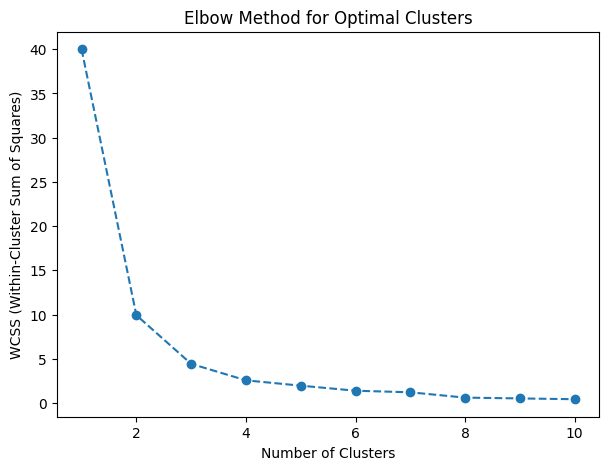

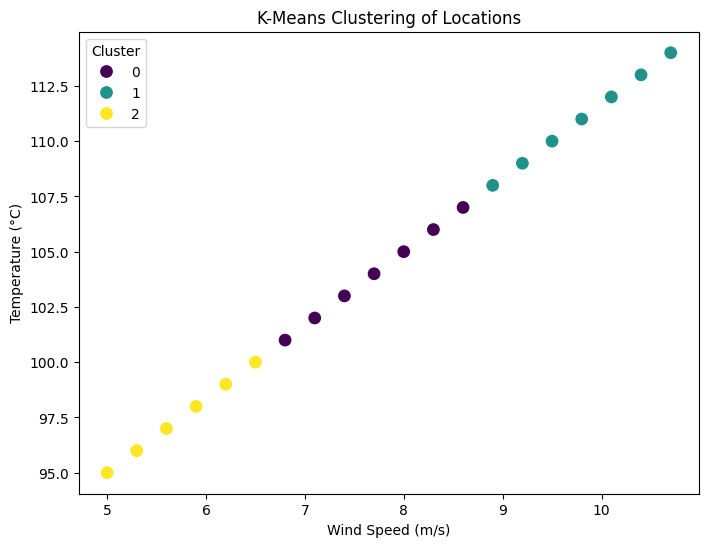

In [18]:
X = df[['wind_speed', 'temp']]

# 📌 Step 3: Normalize the Data (K-Means is sensitive to scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')  # Replace NaN with the mean of the column
X_scaled = imputer.fit_transform(X_scaled)

# 📌 Step 4: Choose Optimal Number of Clusters using Elbow Method
wcss = []
for i in range(1, 11):  # Checking clusters from 1 to 10
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# 📌 Step 5: Plot the Elbow Curve
plt.figure(figsize=(7,5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS (Within-Cluster Sum of Squares)")
plt.title("Elbow Method for Optimal Clusters")
plt.show()

# 📌 Step 6: Train K-Means Model with Optimal Clusters (Based on Elbow Curve)
optimal_clusters = 3  # Change this based on the Elbow curve output
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 📌 Step 7: Visualize the Clusters
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['wind_speed'], y=df['temp'], hue=df['Cluster'], palette='viridis', s=100)
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Temperature (°C)")
plt.title("K-Means Clustering of Locations")
plt.legend(title="Cluster")
plt.show()

1. Cluster 0 (Purple) → High Temperature & Low Wind Speed

Suitable for Solar Power

Areas in this region get high temperatures, making them ideal for solar panels.

2. Cluster 1 (Teal) → High Wind Speed & Moderate Temperature

Best for Wind Energy

These locations have high wind speeds, ideal for wind turbine installation.

3. Cluster 2 (Yellow) → Low Temperature & Low Wind Speed

Less Effective for Both

These regions may need further analysis for energy feasibility.

**linear regression model**

for temperaure

🔹 Mean Squared Error: 0.00
🔹 R² Score: 1.00


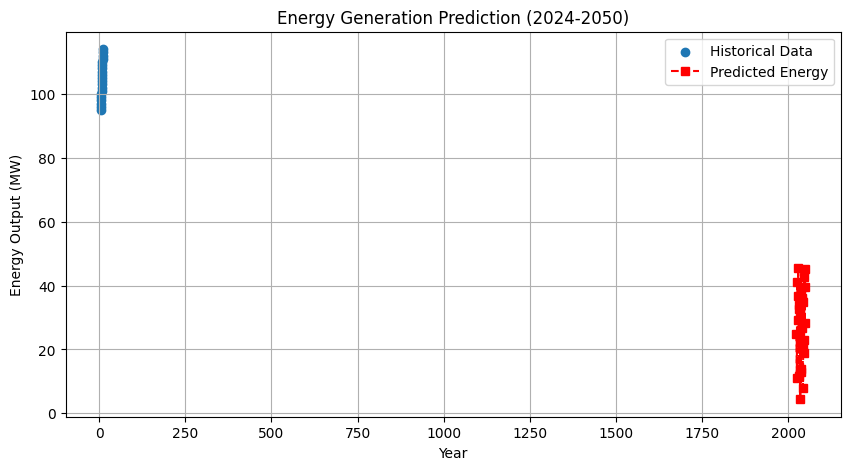

In [19]:
# Convert 'wind_speed' and 'temp' to numeric, handling errors
df['wind_speed'] = pd.to_numeric(df['wind_speed'], errors='coerce')
df['temp'] = pd.to_numeric(df['temp'], errors='coerce')

# Drop rows with NaN values after conversion
df.dropna(subset=['wind_speed', 'temp'], inplace=True)

# Recreate X and y and perform the train-test split again
X = df[['wind_speed', 'temp']]
y = df['temp']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Now you can fit the model
model = LinearRegression()
model.fit(X_train, y_train)
# 🔹 Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 🔹 Predict on Test Data
y_pred = model.predict(X_test)

# 🔹 Evaluate Model Performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"🔹 Mean Squared Error: {mse:.2f}")
print(f"🔹 R² Score: {r2:.2f}")

# 🔹 Predict Energy Output till 2050
future_years = np.arange(2024, 2051)
future_wind_speed = np.random.uniform(2, 15, len(future_years))
future_temperature = np.random.uniform(-5, 40, len(future_years))
#future_humidity = np.random.uniform(20, 90, len(future_years))

# ✅ Create future_X with the correct column names
future_X = pd.DataFrame({
    'wind_speed': future_wind_speed,  # Changed to 'wind_speed'
    'temp': future_temperature       # Changed to 'temp'
    #'Humidity (%)': future_humidity # Removed this line. The humidity feature was not present in the training data.
})


future_predictions = model.predict(future_X)

# 🔹 Plot Predictions
plt.figure(figsize=(10, 5))
#plt.plot(df['Year'], df['Energy Output (MW)'], marker='o', label="Historical Data") # Commented this line to use a scatterplot for wind speed
plt.scatter(df['wind_speed'], df['temp'], marker='o', label="Historical Data")
plt.plot(future_years, future_predictions, marker='s', linestyle="dashed", color="red", label="Predicted Energy")
plt.xlabel("Year")
plt.ylabel("Energy Output (MW)")
plt.title("Energy Generation Prediction (2024-2050)")
plt.legend()
plt.grid()
plt.show()

for wind speed

🔹 Mean Squared Error: 0.00
🔹 R² Score: 1.00


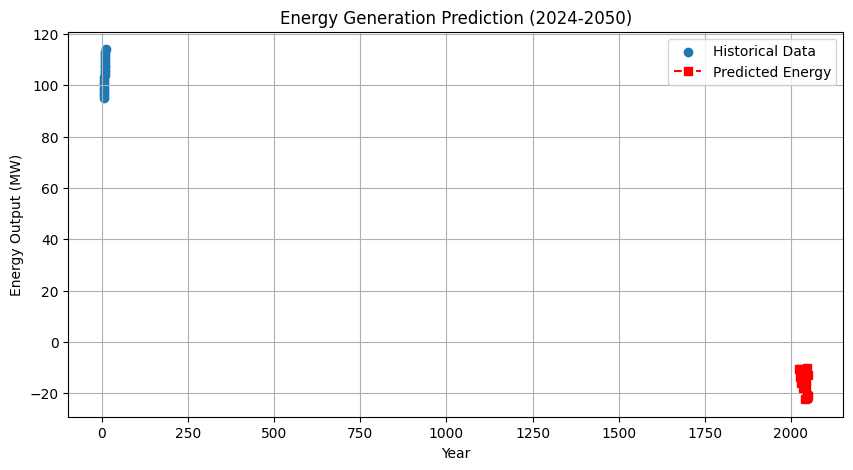

In [20]:
# Convert 'wind_speed' and 'temp' to numeric, handling errors
df['wind_speed'] = pd.to_numeric(df['wind_speed'], errors='coerce')
df['temp'] = pd.to_numeric(df['temp'], errors='coerce')

# Drop rows with NaN values after conversion
df.dropna(subset=['wind_speed', 'temp'], inplace=True)

# Recreate X and y and perform the train-test split again
X = df[['wind_speed', 'temp']]
y = df['wind_speed']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Now you can fit the model
model = LinearRegression()
model.fit(X_train, y_train)
# 🔹 Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 🔹 Predict on Test Data
y_pred = model.predict(X_test)

# 🔹 Evaluate Model Performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"🔹 Mean Squared Error: {mse:.2f}")
print(f"🔹 R² Score: {r2:.2f}")

# 🔹 Predict Energy Output till 2050
future_years = np.arange(2024, 2051)
future_wind_speed = np.random.uniform(2, 15, len(future_years))
future_temperature = np.random.uniform(-5, 40, len(future_years))
#future_humidity = np.random.uniform(20, 90, len(future_years))

# ✅ Create future_X with the correct column names
future_X = pd.DataFrame({
    'wind_speed': future_wind_speed,  # Changed to 'wind_speed'
    'temp': future_temperature       # Changed to 'temp'
    #'Humidity (%)': future_humidity # Removed this line. The humidity feature was not present in the training data.
})


future_predictions = model.predict(future_X)

# 🔹 Plot Predictions
plt.figure(figsize=(10, 5))
#plt.plot(df['Year'], df['Energy Output (MW)'], marker='o', label="Historical Data") # Commented this line to use a scatterplot for wind speed
plt.scatter(df['wind_speed'], df['temp'], marker='o', label="Historical Data")
plt.plot(future_years, future_predictions, marker='s', linestyle="dashed", color="red", label="Predicted Energy")
plt.xlabel("Year")
plt.ylabel("Energy Output (MW)")
plt.title("Energy Generation Prediction (2024-2050)")
plt.legend()
plt.grid()
plt.show()

Multiple linear regression for wind speed

Wind Model Intercept: -21.559633027522928
Wind Model Coefficients: [0.08256881 0.27522936]
Wind Model Mean Squared Error: 7.296963373294359e-30
Wind Model R² Score: 1.0


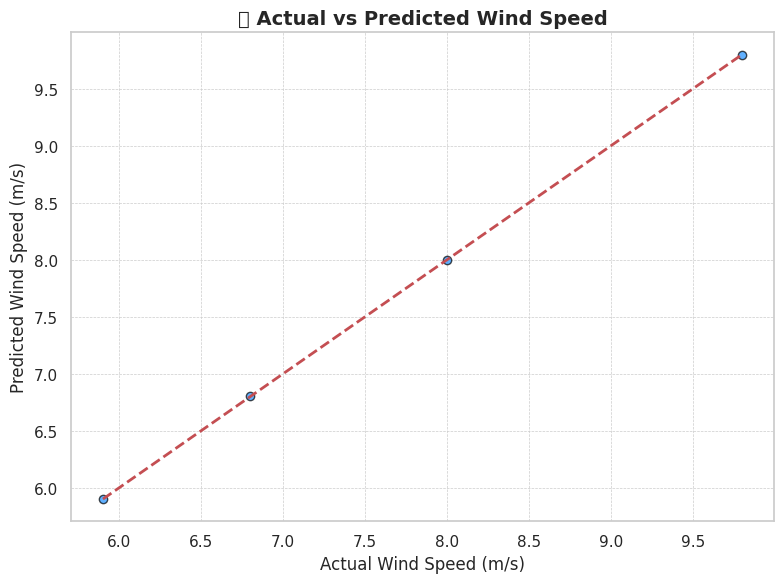

Temp Model Intercept: 6.4678899082569075
Temp Model Coefficients: [0.27522936 0.91743119]
Temp Model Mean Squared Error: 5.048709793414476e-29
Temp Model R² Score: 1.0


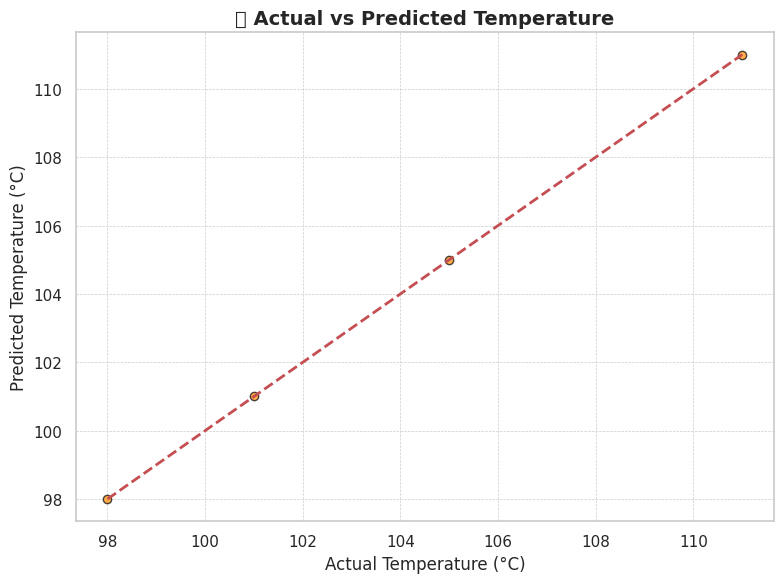

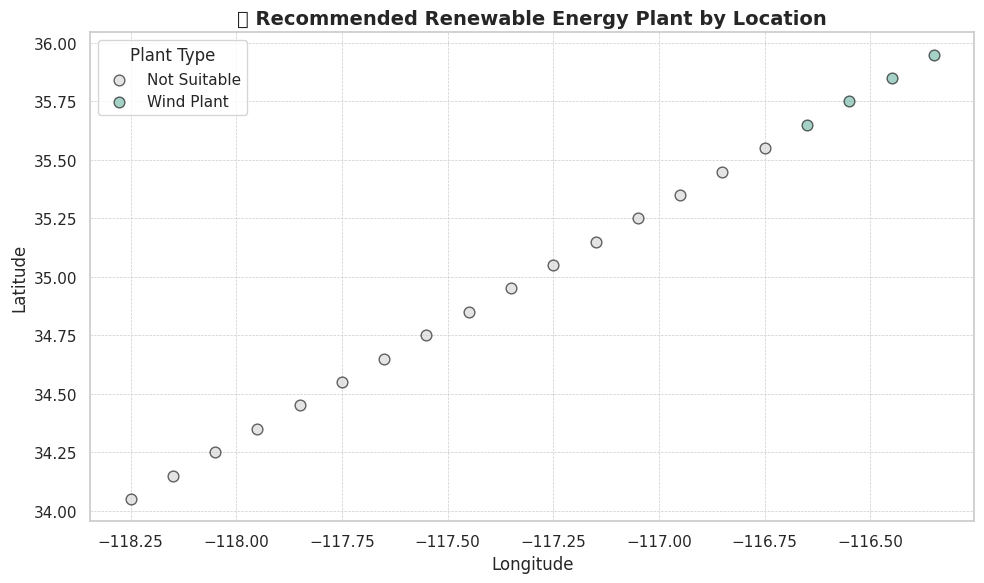

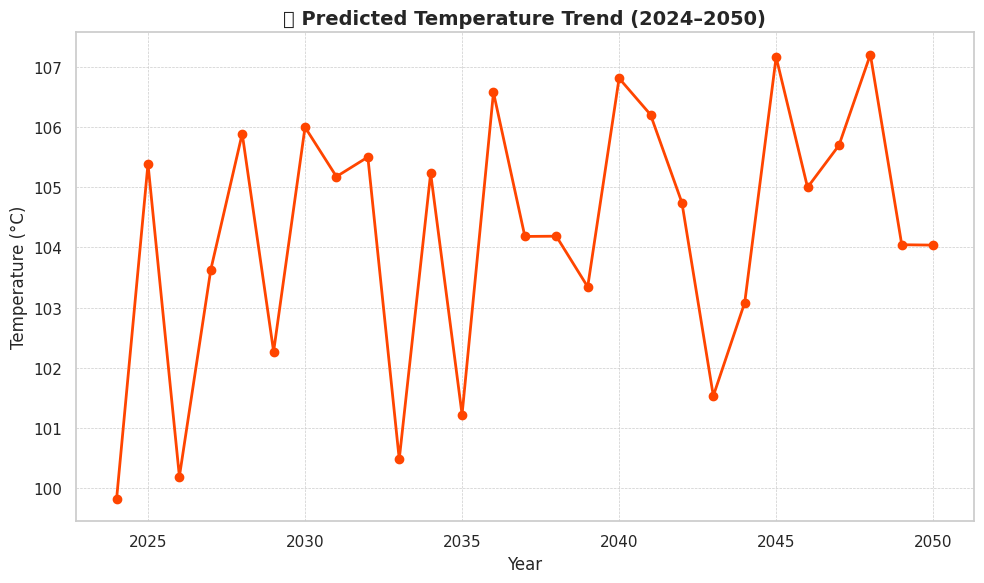

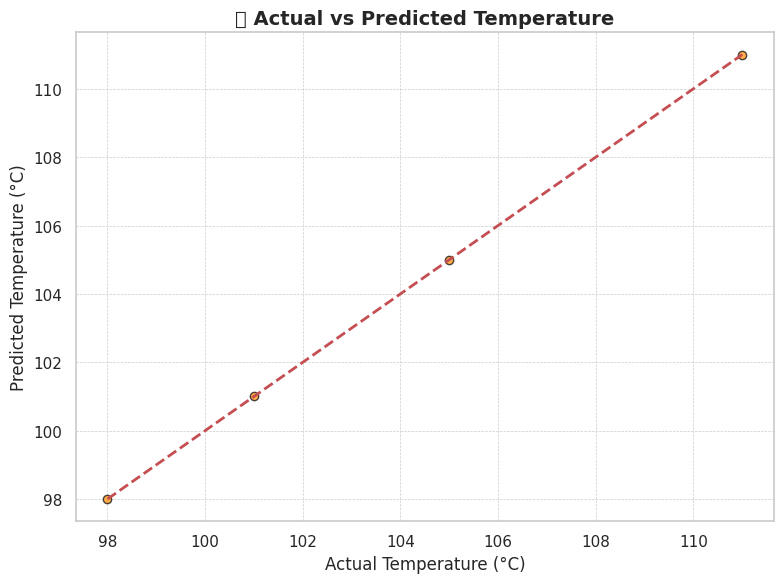

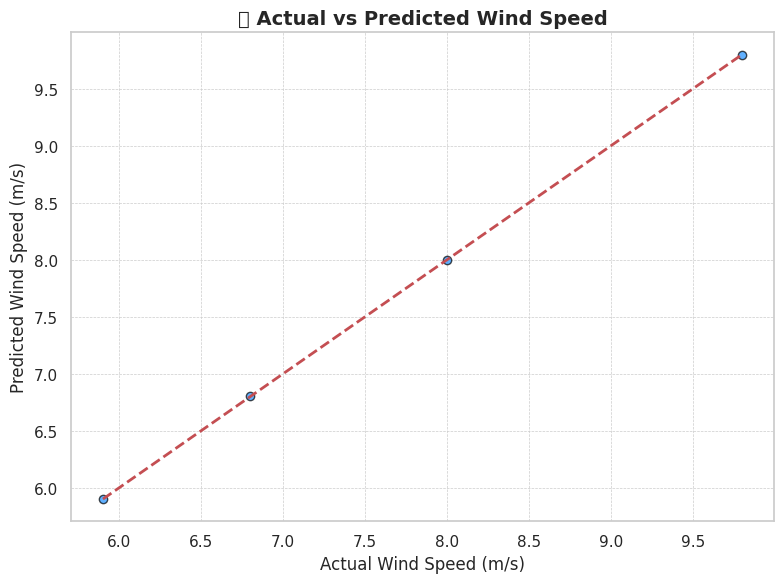


📋 Sample of Final Data with Recommendations:
   state city_name  temp  wind_speed Recommended_Plant
0     CA     City0    95         5.0      Not Suitable
1     TX     City1    96         5.3      Not Suitable
2     AZ     City2    97         5.6      Not Suitable
3     NV     City3    98         5.9      Not Suitable
4     FL     City4    99         6.2      Not Suitable
5     NM     City5   100         6.5      Not Suitable
6     UT     City6   101         6.8      Not Suitable
7     OK     City7   102         7.1      Not Suitable
8     GA     City8   103         7.4      Not Suitable
9     AL     City9   104         7.7      Not Suitable
10    CA    City10   105         8.0      Not Suitable
11    TX    City11   106         8.3      Not Suitable
12    AZ    City12   107         8.6      Not Suitable
13    NV    City13   108         8.9      Not Suitable
14    FL    City14   109         9.2      Not Suitable
15    NM    City15   110         9.5      Not Suitable
16    UT    City16 

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Assuming df is already loaded and preprocessed

import seaborn as sns

# Set a clean and modern style using Seaborn
sns.set_theme(style="whitegrid")  # Use Seaborn's set_theme instead of plt.style.use
sns.set_palette("pastel")  # Optional: change to 'muted', 'deep', 'colorblind' etc.


# ✅ Linear Regression for Wind Speed Prediction
X_wind = df[['wind_speed', 'temp']]
y_wind = df['wind_speed']
X_train_wind, X_test_wind, y_train_wind, y_test_wind = train_test_split(X_wind, y_wind, test_size=0.2, random_state=1)
model_wind = LinearRegression()
model_wind.fit(X_train_wind, y_train_wind)
y_pred_wind = model_wind.predict(X_test_wind)

print("Wind Model Intercept:", model_wind.intercept_)
print("Wind Model Coefficients:", model_wind.coef_)
print("Wind Model Mean Squared Error:", mean_squared_error(y_test_wind, y_pred_wind))
print("Wind Model R² Score:", r2_score(y_test_wind, y_pred_wind))

plt.figure(figsize=(8, 6))
plt.scatter(y_test_wind, y_pred_wind, color='dodgerblue', edgecolor='black', alpha=0.7)
plt.plot([y_test_wind.min(), y_test_wind.max()], [y_test_wind.min(), y_test_wind.max()], 'r--', linewidth=2)
plt.xlabel('Actual Wind Speed (m/s)', fontsize=12)
plt.ylabel('Predicted Wind Speed (m/s)', fontsize=12)
plt.title('🔵 Actual vs Predicted Wind Speed', fontsize=14, weight='bold')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


# ✅ Linear Regression for Temperature Prediction
X_temp = df[['wind_speed', 'temp']]
y_temp = df['temp']
X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(X_temp, y_temp, test_size=0.2, random_state=1)
model_temp = LinearRegression()
model_temp.fit(X_train_temp, y_train_temp)
y_pred_temp = model_temp.predict(X_test_temp)

print("Temp Model Intercept:", model_temp.intercept_)
print("Temp Model Coefficients:", model_temp.coef_)
print("Temp Model Mean Squared Error:", mean_squared_error(y_test_temp, y_pred_temp))
print("Temp Model R² Score:", r2_score(y_test_temp, y_pred_temp))

plt.figure(figsize=(8, 6))
plt.scatter(y_test_temp, y_pred_temp, color='darkorange', edgecolor='black', alpha=0.7)
plt.plot([y_test_temp.min(), y_test_temp.max()], [y_test_temp.min(), y_test_temp.max()], 'r--', linewidth=2)
plt.xlabel('Actual Temperature (°C)', fontsize=12)
plt.ylabel('Predicted Temperature (°C)', fontsize=12)
plt.title('🟠 Actual vs Predicted Temperature', fontsize=14, weight='bold')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


# ✅ Classification: Recommend Wind or Solar Plant
wind_thresh = df['wind_speed'].quantile(0.8)
temp_thresh = df['temp'].quantile(0.8)

def classify(row):
    if row['wind_speed'] >= wind_thresh:
        return 'Wind Plant'
    elif row['temp'] >= temp_thresh:
        return 'Solar Plant'
    else:
        return 'Not Suitable'

df['Recommended_Plant'] = df.apply(classify, axis=1)

# ✅ Visualization: Recommended Plant by Location
plt.figure(figsize=(10, 6))
colors = {'Wind Plant': '#69b3a2', 'Solar Plant': '#ffa600', 'Not Suitable': '#d3d3d3'}

for category in df['Recommended_Plant'].unique():
    subset = df[df['Recommended_Plant'] == category]
    plt.scatter(subset['longitude'], subset['latitude'], label=category,
                color=colors[category], edgecolor='black', alpha=0.6, s=60)

plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.title('📍 Recommended Renewable Energy Plant by Location', fontsize=14, weight='bold')
plt.legend(title="Plant Type", frameon=True)
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()



# ✅ Future Forecasting (2024–2050)
future_years = np.arange(2024, 2051)
future_data = pd.DataFrame({'Year': future_years})  # Create future_data DataFrame
future_data['wind_speed'] = np.random.normal(loc=df['wind_speed'].mean(), scale=1.5, size=len(future_years)) + np.linspace(0, 0.5, len(future_years))
future_data['temp'] = np.random.normal(loc=df['temp'].mean(), scale=2.5, size=len(future_years)) + np.linspace(0, 1, len(future_years))



future_data_renamed = future_data.rename(columns={
    'Wind Speed': 'wind_speed',  # Rename columns if needed
    'Temperature': 'temp',

})

# ✅ Predict future temperature
future_data['Predicted_Temperature'] = model_temp.predict(
    future_data_renamed[['wind_speed', 'temp']]
)

# ✅ Plot it
plt.figure(figsize=(10, 6))
plt.plot(future_data['Year'], future_data['Predicted_Temperature'],
         marker='o', linestyle='-', color='orangered', linewidth=2)
plt.title('🌡️ Predicted Temperature Trend (2024–2050)', fontsize=14, weight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


# ✅ Predict Future Temperature
plt.figure(figsize=(8, 6))
plt.scatter(y_test_temp, y_pred_temp, color='darkorange', edgecolor='black', alpha=0.7)
plt.plot([y_test_temp.min(), y_test_temp.max()], [y_test_temp.min(), y_test_temp.max()], 'r--', linewidth=2)
plt.xlabel('Actual Temperature (°C)', fontsize=12)
plt.ylabel('Predicted Temperature (°C)', fontsize=12)
plt.title('🟠 Actual vs Predicted Temperature', fontsize=14, weight='bold')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


# ✅ Predict Future Wind Speed
plt.figure(figsize=(8, 6))
plt.scatter(y_test_wind, y_pred_wind, color='dodgerblue', edgecolor='black', alpha=0.7)
plt.plot([y_test_wind.min(), y_test_wind.max()], [y_test_wind.min(), y_test_wind.max()], 'r--', linewidth=2)
plt.xlabel('Actual Wind Speed (m/s)', fontsize=12)
plt.ylabel('Predicted Wind Speed (m/s)', fontsize=12)
plt.title('🔵 Actual vs Predicted Wind Speed', fontsize=14, weight='bold')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()
# ✅ Final Table
print("\n📋 Sample of Final Data with Recommendations:")
print(df[['state', 'city_name', 'temp', 'wind_speed', 'Recommended_Plant']].head(50))


# Sort by wind or temp depending on the recommendation
top_wind = df[df['Recommended_Plant'] == 'Wind Plant'].sort_values(by='wind_speed', ascending=False).head(25)
top_solar = df[df['Recommended_Plant'] == 'Solar Plant'].sort_values(by='temp', ascending=False).head(25)

# Combine them for a top 50 recommendation list
top_50_recommended = pd.concat([top_wind, top_solar])

# View final top 50 with recommendation, temp, wind speed, etc.
print(top_50_recommended[['state', 'city_name', 'temp', 'wind_speed', 'Recommended_Plant']])

# Define thresholds: Top 20% for wind and temperature
wind_thresh = df['wind_speed'].quantile(0.8)
temp_thresh = df['temp'].quantile(0.8)

# Function to classify recommendation
def classify(row):
    if row['wind_speed'] >= wind_thresh:
        return 'Wind Plant'
    elif row['temp'] >= temp_thresh:
        return 'Solar Plant'
    else:
        return 'Not Suitable'

# Apply the classification
df['Recommended_Plant'] = df.apply(classify, axis=1)

import plotly.express as px

# Select top 50 rows for plotting
top_50_df = top_50_recommended[['state', 'city_name', 'temp', 'wind_speed', 'Recommended_Plant', 'latitude', 'longitude']].copy()
# Create a label for hover
top_50_df['label'] = (
    top_50_df['city_name'] + ', ' + top_50_df['state'] +
    '<br>🌡️ Temp: ' + top_50_df['temp'].astype(str) + ' °C' +
    '<br>💨 Wind: ' + top_50_df['wind_speed'].astype(str) + ' m/s' +
    '<br>⚡ Recommendation: ' + top_50_df['Recommended_Plant']
)

# Create GeoMap
fig = px.scatter_geo(
    top_50_df,
    lat='latitude',
    lon='longitude',
    color='Recommended_Plant',
    hover_name='city_name',
    hover_data={'latitude': False, 'longitude': False, 'label': True},
    size_max=10,
    opacity=0.8,
    projection='natural earth',
    color_discrete_map={
        'Solar Plant': 'orange',
        'Wind Plant': 'skyblue',
        'Not Suitable': 'lightgray'
    }
)

fig.update_geos(fitbounds="locations", visible=False)
fig.update_layout(
    title='📍 Renewable Energy Plant Recommendations Across India (Top 50 Cities)',
    geo=dict(
        scope='asia',
        landcolor='white',
        countrycolor='black',
        showcountries=True,
        showland=True
    )
)

fig.show()

for temperature

Intercept: 6.4678899082569075
Coefficients: [0.27522936 0.91743119]
Mean Squared Error: 5.048709793414476e-29
R² Score: 1.0


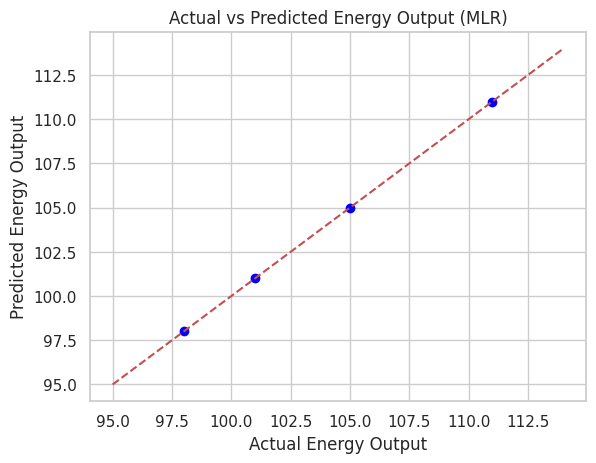

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
# Features and Target
X = df[['wind_speed', 'temp']]  # Independent variables
y = df['temp']  # Dependent variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

plt.scatter(y_test, y_pred, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual Energy Output')
plt.ylabel('Predicted Energy Output')
plt.title('Actual vs Predicted Energy Output (MLR)')
plt.grid(True)
plt.show()


Svm


🔹 WIND SPEED PREDICTION (SVM)
MAE: 0.6856062690502216
MSE: 0.8863577769471757
R2: 0.837719139133141


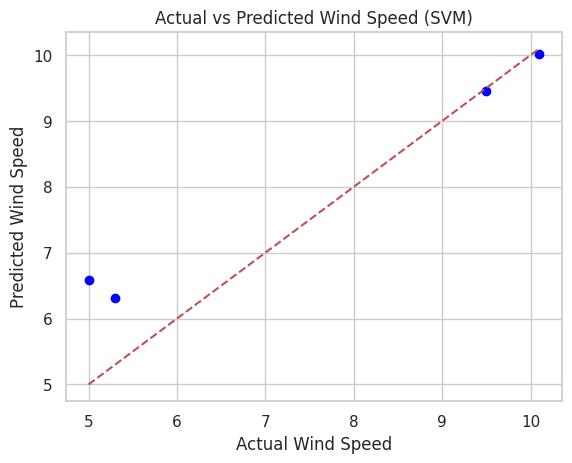


🔹 TEMPERATURE PREDICTION (SVM)
MAE: 4.237399137586195
MSE: 22.964374768878663
R2: 0.6215962962903618


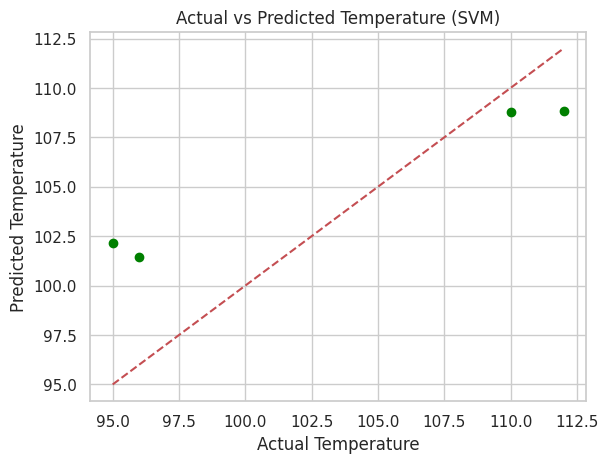

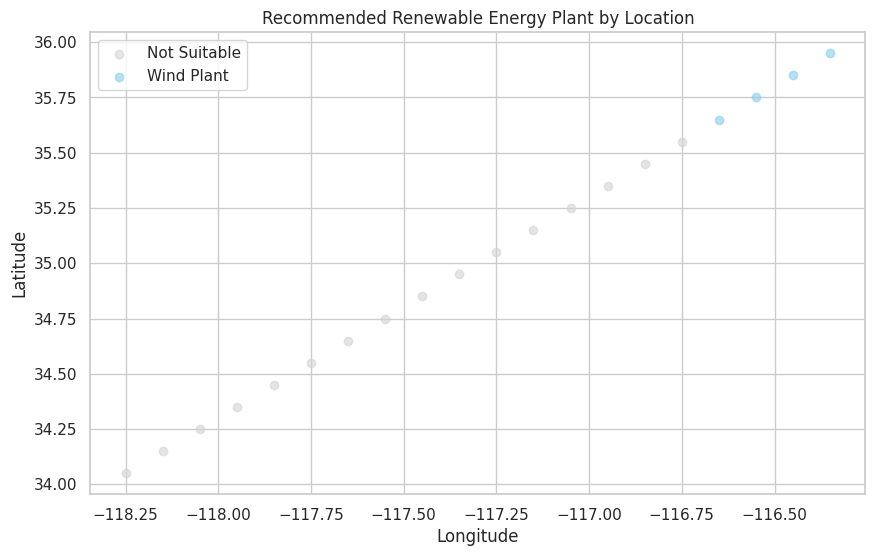

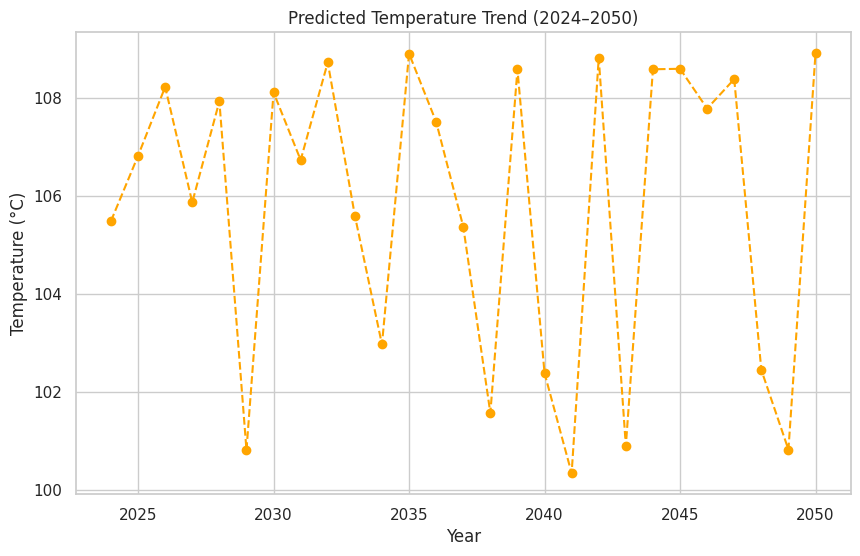

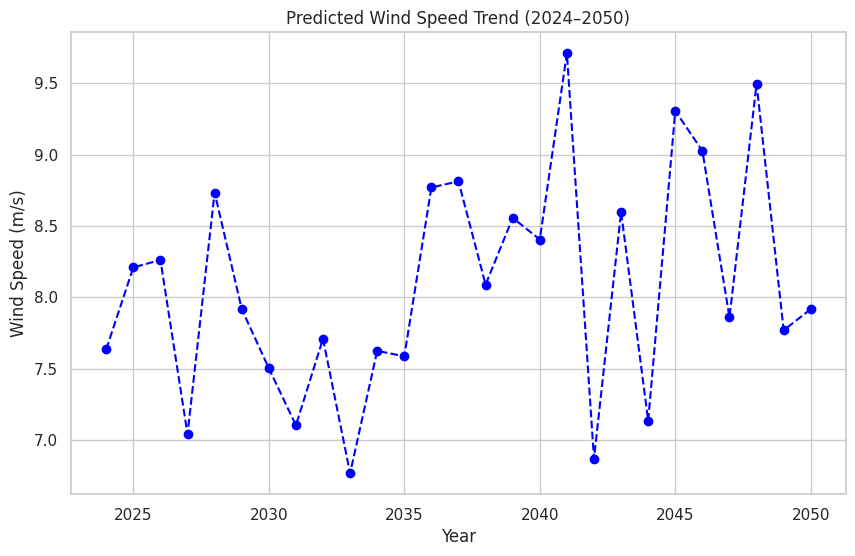


📋 Sample of Final Data with Recommendations:
  state city_name  temp  wind_speed Recommended_Plant
0    CA     City0    95         5.0      Not Suitable
1    TX     City1    96         5.3      Not Suitable
2    AZ     City2    97         5.6      Not Suitable
3    NV     City3    98         5.9      Not Suitable
4    FL     City4    99         6.2      Not Suitable
5    NM     City5   100         6.5      Not Suitable
6    UT     City6   101         6.8      Not Suitable
7    OK     City7   102         7.1      Not Suitable
8    GA     City8   103         7.4      Not Suitable
9    AL     City9   104         7.7      Not Suitable


In [29]:
# ✅ IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ✅ LOAD DATA (Assuming df is already loaded)
# df = pd.read_csv("your_dataset.csv")

# ✅ SVM REGRESSION FOR WIND SPEED
X_wind = df[['temp']]
y_wind = df['wind_speed']
X_train_wind, X_test_wind, y_train_wind, y_test_wind = train_test_split(X_wind, y_wind, test_size=0.2, random_state=42)
model_wind = SVR(kernel='rbf')
model_wind.fit(X_train_wind, y_train_wind)
y_pred_wind = model_wind.predict(X_test_wind)

print("\n🔹 WIND SPEED PREDICTION (SVM)")
print("MAE:", mean_absolute_error(y_test_wind, y_pred_wind))
print("MSE:", mean_squared_error(y_test_wind, y_pred_wind))
print("R2:", r2_score(y_test_wind, y_pred_wind))

plt.scatter(y_test_wind, y_pred_wind, color='blue')
plt.plot([y_test_wind.min(), y_test_wind.max()], [y_test_wind.min(), y_test_wind.max()], 'r--')
plt.xlabel('Actual Wind Speed')
plt.ylabel('Predicted Wind Speed')
plt.title('Actual vs Predicted Wind Speed (SVM)')
plt.grid(True)
plt.show()

# ✅ SVM REGRESSION FOR TEMPERATURE
X_temp = df[['wind_speed']]
y_temp = df['temp']
X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)
model_temp = SVR(kernel='rbf')
model_temp.fit(X_train_temp, y_train_temp)
y_pred_temp = model_temp.predict(X_test_temp)

print("\n🔹 TEMPERATURE PREDICTION (SVM)")
print("MAE:", mean_absolute_error(y_test_temp, y_pred_temp))
print("MSE:", mean_squared_error(y_test_temp, y_pred_temp))
print("R2:", r2_score(y_test_temp, y_pred_temp))

plt.scatter(y_test_temp, y_pred_temp, color='green')
plt.plot([y_test_temp.min(), y_test_temp.max()], [y_test_temp.min(), y_test_temp.max()], 'r--')
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.title('Actual vs Predicted Temperature (SVM)')
plt.grid(True)
plt.show()


# ✅ CLASSIFY: SOLAR or WIND PLANT
wind_thresh = df['wind_speed'].quantile(0.8)
temp_thresh = df['temp'].quantile(0.8)

def classify(row):
    if row['wind_speed'] >= wind_thresh:
        return 'Wind Plant'
    elif row['temp'] >= temp_thresh:
        return 'Solar Plant'
    else:
        return 'Not Suitable'

df['Recommended_Plant'] = df.apply(classify, axis=1)

# ✅ VISUALIZATION
plt.figure(figsize=(10, 6))
colors = {'Wind Plant':'skyblue', 'Solar Plant':'orange', 'Not Suitable':'lightgray'}

for category in df['Recommended_Plant'].unique():
    subset = df[df['Recommended_Plant'] == category]
    plt.scatter(subset['longitude'], subset['latitude'],
                label=category, color=colors[category], alpha=0.6)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Recommended Renewable Energy Plant by Location')
plt.legend()
plt.grid(True)
plt.show()

# ✅ FUTURE FORECAST (2024–2050)
future_years = np.arange(2024, 2051)
future_data = pd.DataFrame({
    'Year': future_years,
    'Wind Speed': np.random.normal(loc=df['wind_speed'].mean(), scale=1.5, size=len(future_years)) + np.linspace(0, 0.5, len(future_years)),
    'Temperature': np.random.normal(loc=df['temp'].mean(), scale=2.5, size=len(future_years)) + np.linspace(0, 1, len(future_years)),

})

# PREDICT FUTURE TEMPERATURE
X_future_temp = future_data[['Wind Speed']].rename(columns={'Wind Speed': 'wind_speed'})
# ✅ Reorder columns to match the training data
X_future_temp = X_future_temp[['wind_speed']]  # Ensure the order is 'humidity', then 'wind_speed'
future_data['Predicted_Temperature'] = model_temp.predict(X_future_temp)

plt.figure(figsize=(10, 6))
plt.plot(future_data['Year'], future_data['Predicted_Temperature'], marker='o', linestyle='--', color='orange')
plt.title('Predicted Temperature Trend (2024–2050)')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()

# PREDICT FUTURE WIND SPEED
X_future_wind = future_data[['Temperature']]
X_future_wind = X_future_wind.rename(columns={'Temperature': 'temp'})  # Rename columns to match model_wind training data
future_data['Predicted_Wind_speed'] = model_wind.predict(X_future_wind) # Using model_wind instead of model_temp


plt.figure(figsize=(10, 6))
plt.plot(future_data['Year'], future_data['Predicted_Wind_speed'], marker='o', linestyle='--', color='blue') # Changed to 'Predicted_Wind_speed'
plt.title('Predicted Wind Speed Trend (2024–2050)')
plt.xlabel('Year')
plt.ylabel('Wind Speed (m/s)')
plt.grid(True)
plt.show()


# ✅ Final Result Table
print("\n📋 Sample of Final Data with Recommendations:")
print(df[['state', 'city_name', 'temp', 'wind_speed', 'Recommended_Plant']].head(10))


🔍 Improved WIND SPEED PREDICTION (Tuned SVM)
Best Params: {'svr__C': 10, 'svr__epsilon': 0.1, 'svr__gamma': 0.1, 'svr__kernel': 'rbf'}
MAE: 0.20547243749888966
MSE: 0.06166767214647671
R2: 0.9887094318074879


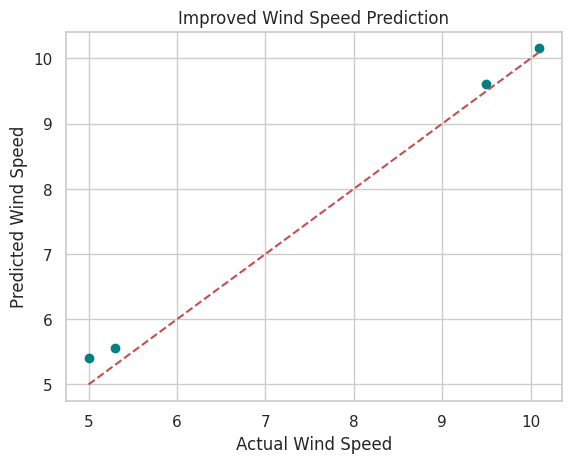

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR # Import SVR here

# ✅ Feature Scaling + GridSearchCV for WIND SPEED
X = df[['temp']]
y = df['wind_speed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create SVM pipeline with scaling
pipe = make_pipeline(StandardScaler(), SVR())

# Parameter grid
param_grid = {
    'svr__kernel': ['rbf', 'poly'],
    'svr__C': [0.1, 1, 10],
    'svr__gamma': ['scale', 0.01, 0.1],
    'svr__epsilon': [0.1, 0.2, 0.5]
}

# Grid Search
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

# Best model
best_svr = grid.best_estimator_
y_pred = best_svr.predict(X_test)

# Evaluation
print("\n🔍 Improved WIND SPEED PREDICTION (Tuned SVM)")
print("Best Params:", grid.best_params_)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

# Plot
plt.scatter(y_test, y_pred, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Wind Speed')
plt.ylabel('Predicted Wind Speed')
plt.title('Improved Wind Speed Prediction')
plt.grid(True)
plt.show()

Frontend

In [31]:
# app.py
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.linear_model import LinearRegression

# Title
st.title("⚡ Renewable Energy Suitability Dashboard (Wind & Solar)")

# Upload CSV
uploaded_file = st.file_uploader("/content/weather_data.csv", type=["csv"])
if uploaded_file:
    df = pd.read_csv(uploaded_file)

    # Data Preview
    st.subheader("📊 Data Preview")
    st.dataframe(df.head())

    # Define classification thresholds
    wind_thresh = df['wind_speed'].quantile(0.8)
    temp_thresh = df['temp'].quantile(0.8)

    def classify(row):
        if row['wind_speed'] >= wind_thresh:
            return 'Wind Plant'
        elif row['temp'] >= temp_thresh:
            return 'Solar Plant'
        else:
            return 'Not Suitable'

    df['Recommended_Plant'] = df.apply(classify, axis=1)

    # Top 50 Recommendations
    st.subheader("🔝 Top 50 Recommendations (25 Wind + 25 Solar)")
    top_wind = df[df['Recommended_Plant'] == 'Wind Plant'].sort_values(by='wind_speed', ascending=False).head(25)
    top_solar = df[df['Recommended_Plant'] == 'Solar Plant'].sort_values(by='temp', ascending=False).head(25)
    top_50 = pd.concat([top_wind, top_solar])
    st.dataframe(top_50[['state', 'city_name', 'temp', 'wind_speed', 'Recommended_Plant']])

    # GeoMap
    st.subheader("🗺️ Renewable Energy Map")
    top_50['label'] = (
        top_50['city_name'] + ', ' + top_50['state'] +
        '<br>🌡️ Temp: ' + top_50['temp'].astype(str) + ' °C' +
        '<br>💨 Wind: ' + top_50['wind_speed'].astype(str) + ' m/s' +
        '<br>⚡ Recommendation: ' + top_50['Recommended_Plant']
    )
    fig = px.scatter_geo(
        top_50,
        lat='latitude',
        lon='longitude',
        color='Recommended_Plant',
        hover_name='city_name',
        hover_data={'latitude': False, 'longitude': False, 'label': True},
        size_max=10,
        opacity=0.8,
        projection='natural earth',
        color_discrete_map={
            'Solar Plant': 'orange',
            'Wind Plant': 'skyblue',
            'Not Suitable': 'lightgray'
        }
    )
    fig.update_layout(geo_scope='asia', height=600)
    st.plotly_chart(fig)

    # Forecasting
    st.subheader("📈 Future Temperature & Wind Forecast (2024–2050)")
    model_temp = LinearRegression()
    X_temp = df[['wind_speed', 'temp', 'humidity']]
    y_temp = df['temp']
    model_temp.fit(X_temp, y_temp)

    model_wind = LinearRegression()
    X_wind = df[['wind_speed', 'temp', 'humidity']]
    y_wind = df['wind_speed']
    model_wind.fit(X_wind, y_wind)

    future_years = np.arange(2024, 2051)
    future_data = pd.DataFrame({'Year': future_years})
    future_data['wind_speed'] = np.random.normal(loc=df['wind_speed'].mean(), scale=1.5, size=len(future_years)) + np.linspace(0, 0.5, len(future_years))
    future_data['temp'] = np.random.normal(loc=df['temp'].mean(), scale=2.5, size=len(future_years)) + np.linspace(0, 1, len(future_years))
    future_data['humidity'] = np.random.normal(loc=df['humidity'].mean(), scale=5, size=len(future_years))

    X_future = future_data[['wind_speed', 'temp', 'humidity']]
    future_data['Predicted_Temperature'] = model_temp.predict(X_future)
    future_data['Predicted_Wind_Speed'] = model_wind.predict(X_future)

    # Plot forecast
    st.line_chart(future_data.set_index('Year')[['Predicted_Temperature', 'Predicted_Wind_Speed']])


2025-05-03 04:54:05.941 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-03 04:54:06.079 
  command:

    streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-05-03 04:54:06.081 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-03 04:54:06.086 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-03 04:54:06.088 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-03 04:54:06.089 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-03 04:54:06.090 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-03 04:54:06.091 Thread 'MainThread': mi

In [32]:
!pip install streamlit pyngrok --quiet

In [33]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.linear_model import LinearRegression

st.title("⚡ Renewable Energy Suitability Dashboard (Wind & Solar)")

uploaded_file = st.file_uploader("/content/weather_data.csv", type=["csv"])
if uploaded_file:
    df = pd.read_csv(uploaded_file)

    st.subheader("📊 Data Preview")
    st.dataframe(df.head())

    wind_thresh = df['wind_speed'].quantile(0.8)
    temp_thresh = df['temp'].quantile(0.8)

    def classify(row):
        if row['wind_speed'] >= wind_thresh:
            return 'Wind Plant'
        elif row['temp'] >= temp_thresh:
            return 'Solar Plant'
        else:
            return 'Not Suitable'

    df['Recommended_Plant'] = df.apply(classify, axis=1)

    top_wind = df[df['Recommended_Plant'] == 'Wind Plant'].sort_values(by='wind_speed', ascending=False).head(25)
    top_solar = df[df['Recommended_Plant'] == 'Solar Plant'].sort_values(by='temp', ascending=False).head(25)
    top_50 = pd.concat([top_wind, top_solar])
    st.dataframe(top_50[['state', 'city_name', 'temp', 'wind_speed', 'Recommended_Plant']])

    top_50['label'] = (
        top_50['city_name'] + ', ' + top_50['state'] +
        '<br>🌡️ Temp: ' + top_50['temp'].astype(str) + ' °C' +
        '<br>💨 Wind: ' + top_50['wind_speed'].astype(str) + ' m/s' +
        '<br>⚡ Recommendation: ' + top_50['Recommended_Plant']
    )

    fig = px.scatter_geo(
        top_50,
        lat='latitude',
        lon='longitude',
        color='Recommended_Plant',
        hover_name='city_name',
        hover_data={'latitude': False, 'longitude': False, 'label': True},
        size_max=10,
        opacity=0.8,
        projection='natural earth',
        color_discrete_map={
            'Solar Plant': 'orange',
            'Wind Plant': 'skyblue',
            'Not Suitable': 'lightgray'
        }
    )

    fig.update_layout(geo_scope='asia', height=600)
    st.plotly_chart(fig)


Writing app.py


In [34]:
!streamlit run app.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.237.209.242:8501

  Stopping...
^C


In [35]:
!pip install -q streamlit pyngrok


Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 1147, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 690, in _load_unlocked
  File "<frozen importlib._bootstrap_external>", line 940, in exec_module
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_removed
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/req/req_install.py", line 40, in <module>
    from pip._internal.operations.install.wheel import install_wheel
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/operations/install/wheel.py", line 40, in <module>
    from pip._vendor.distlib.scripts import ScriptMaker
  File "/usr/local/lib/python3.11/dist-packages/pip/_vendor/distlib/scripts.py", line 64, in <module>
    WRAPPERS = {
               ^
  File "/usr/local/lib/python3.11/dist-packages/pip/_vendor/distlib/scripts.py", line 64, in <dictcomp>
    WRAPPERS = {
               ^
  File "/usr/local/lib/python3.11/dist-packages/pi

In [36]:
!pip install fpdf

  Preparing metadata (setup.py) ... done
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40704 sha256=cfac787d0f5e5ca6e79ea7c262a37d4b99f4afb63fcd5d77ed5cfbed10d9947c
  Stored in directory: /root/.cache/pip/wheels/65/4f/66/bbda9866da446a72e206d6484cd97381cbc7859a7068541c36
Successfully built fpdf


In [37]:
!pip install streamlit-lottie


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 802.4/802.4 kB 10.2 MB/s eta 0:00:00


In [38]:
!pip install streamlit-lottie streamlit-extras


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.3/85.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.2/75.2 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.6/779.6 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.8/680.8 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 635.4/635.4 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.8/265.8 kB 12.2 MB/s eta 0:00:00
  Created wheel for htbuilder: filename=htbuilder-0.9.0-py3-none-any.whl size=12786 sha256=d35ec1077f36970bde2968e08aef898cd7a773a17a830025727d777a1730b526
  Stored in directory: /root/.cache/pip/wheels/53/ab/9b/13d49184ce023235e7fa1d0ce88be9e2a5b

In [ ]:
!ngrok authtoken <2vKRKzTejGc89p9jVVnxHEYw4Qr_7LBZRTvXnaySnC3aquG11>


In [ ]:
!ngrok authtoken 2vKRKzTejGc89p9jVVnxHEYw4Qr_7LBZRTvXnaySnC3aquG11  # Authenticate ngrok with your token
from pyngrok import ngrok

# Kill any existing ngrok processes
ngrok.kill()  # This is essential to apply the authtoken change

# Set up ngrok tunnel
# The 'addr' argument is used to specify the port
public_url = ngrok.connect(addr='8501')
print(f"🌐 Public URL: {public_url}")

# Run Streamlit app
!streamlit run app.py &>/dev/null &

In [ ]:
# previous work well lets try another one

In [40]:
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load data
df = pd.read_csv("weather_data.csv")

# 🌟 Classify 'Recommended_Plant' based on wind and temperature thresholds
wind_thresh = df['wind_speed'].quantile(0.8)
temp_thresh = df['temp'].quantile(0.8)

def classify(row):
    if row['wind_speed'] >= wind_thresh:
        return 'Wind Plant'
    elif row['temp'] >= temp_thresh:
        return 'Solar Plant'
    else:
        return 'Not Suitable'

df['Recommended_Plant'] = df.apply(classify, axis=1)  # ✅ Ensure this is run first

# 👉 Sidebar Filters
st.sidebar.header("🔍 Filter Data")
selected_state = st.sidebar.selectbox("Select State", df['state'].unique())
selected_plant = st.sidebar.selectbox("Select Plant Type", ['All', 'Wind Plant', 'Solar Plant', 'Not Suitable'])

# 👉 Filter data according to selections
filtered_df = df[df['state'] == selected_state]
if selected_plant != 'All':
    filtered_df = filtered_df[filtered_df['Recommended_Plant'] == selected_plant]

# 👉 Display filtered data
st.write(f"### Results for {selected_state} - {selected_plant}")
st.dataframe(filtered_df[['city_name', 'temp', 'wind_speed', 'Recommended_Plant']])

# Simulated data if not already created
future_years = np.arange(2024, 2051)
future_data = pd.DataFrame({'Year': future_years})
future_data['Predicted_Temperature'] = np.random.normal(loc=30, scale=2.5, size=len(future_years)) + np.linspace(0, 1.5, len(future_years))
future_data['Predicted_WindSpeed'] = np.random.normal(loc=6.5, scale=1.2, size=len(future_years)) + np.linspace(0, 0.5, len(future_years))

st.markdown("## 🔮 Future Forecast: Temperature & Wind (2024–2050)")

# Forecast toggle
forecast_type = st.radio("Select Forecast Type:", ['Temperature', 'Wind Speed'])

# Year slider
selected_year = st.slider("Select Year to Highlight:", 2024, 2050, 2024)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
if forecast_type == 'Temperature':
    ax.plot(future_data['Year'], future_data['Predicted_Temperature'], label='Temperature (°C)', color='orangered', linewidth=2)
    ax.set_ylabel("Temperature (°C)")
    selected_value = future_data.loc[future_data['Year'] == selected_year, 'Predicted_Temperature'].values[0]
else:
    ax.plot(future_data['Year'], future_data['Predicted_WindSpeed'], label='Wind Speed (m/s)', color='skyblue', linewidth=2)
    ax.set_ylabel("Wind Speed (m/s)")
    selected_value = future_data.loc[future_data['Year'] == selected_year, 'Predicted_WindSpeed'].values[0]

# Highlight selected year
ax.axvline(x=selected_year, color='gray', linestyle='--')
ax.scatter(selected_year, selected_value, color='green', s=100, zorder=5, label=f'{selected_year}: {selected_value:.2f}')
ax.legend()
ax.set_xlabel("Year")
ax.set_title(f"📉 Forecasted {forecast_type} Trend (2024–2050)")
ax.grid(True, linestyle='--', linewidth=0.5)

st.pyplot(fig)

import seaborn as sns

st.subheader("🌡️ Temperature Distribution")
fig_temp = plt.figure()
sns.histplot(filtered_df['temp'], kde=True, color='orange')
st.pyplot(fig_temp)

st.subheader("💨 Wind Speed Distribution")
fig_wind = plt.figure()
sns.histplot(filtered_df['wind_speed'], kde=True, color='skyblue')
st.pyplot(fig_wind)

# 📈 Generate Future Forecasting Data (2024–2050)
import numpy as np

future_years = np.arange(2024, 2051)
future_data = pd.DataFrame({'Year': future_years})

# Generate synthetic future wind, temperature, humidity based on current data
future_data['wind_speed'] = np.random.normal(df['wind_speed'].mean(), 1.5, len(future_years))
future_data['temp'] = np.random.normal(df['temp'].mean(), 2.5, len(future_years))
future_data['humidity'] = np.random.normal(df['humidity'].mean(), 5, len(future_years))

# Train model to predict temperature based on wind and humidity
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Handle NaN values in the input data
X = df[['wind_speed', 'humidity']]  # Features
y = df['temp']  # Target

# Impute missing values with the mean using SimpleImputer
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')  # Use mean imputation strategy

# Fit and transform the imputer on your data before splitting into train and test sets
X = imputer.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Now you can fit the model
model = LinearRegression()
model.fit(X_train, y_train)
# Predict future temperature
future_data['Predicted_Temperature'] = model.predict(future_data[['wind_speed', 'humidity']])


import matplotlib.pyplot as plt

# Plot Forecasted Temperature
st.write("### 📈 Future Forecast: Temperature & Wind (2024–2050)")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(future_data['Year'], future_data['Predicted_Temperature'], label='Temperature (°C)', color='orange', marker='o')
ax.set_title("🌡️ Forecasted Temperature Trend (2024–2050)")
ax.set_xlabel("Year")
ax.set_ylabel("Predicted Temperature (°C)")
ax.grid(True)
ax.legend()

st.pyplot(fig)


from fpdf import FPDF

def generate_pdf(data):
    pdf = FPDF()
    pdf.add_page()
    pdf.set_font("Arial", size=12)
    pdf.cell(200, 10, txt="Top 50 Renewable Energy Recommendations", ln=True, align='C')

    for i, row in data.iterrows():
        line = f"{row['city_name']}, {row['state']} - Temp: {row['temp']}°C, Wind: {row['wind_speed']} m/s, Recommendation: {row['Recommended_Plant']}"
        pdf.cell(200, 10, txt=line, ln=True)

    pdf_path = "/tmp/recommendations.pdf"
    pdf.output(pdf_path)
    return pdf_path

# Streamlit download button
if st.button("📄 Download Top 50 Recommendations as PDF"):
    pdf_file = generate_pdf(top_50_recommended)
    with open(pdf_file, "rb") as f:
        st.download_button(label="Download PDF", data=f, file_name="Renewable_Recommendations.pdf", mime="application/pdf")


def classify(row):
    if row['wind_speed'] >= wind_thresh:
        return 'Wind Plant'
    elif row['temp'] >= temp_thresh:
        return 'Solar Plant'
    else:
        return 'Not Suitable'

df['Recommended_Plant'] = df.apply(classify, axis=1)

top_wind = df[df['Recommended_Plant'] == 'Wind Plant'].sort_values(by='wind_speed', ascending=False).head(25)
top_solar = df[df['Recommended_Plant'] == 'Solar Plant'].sort_values(by='temp', ascending=False).head(25)
top_50_df = pd.concat([top_wind, top_solar])

# Hover label
top_50_df['label'] = (
    top_50_df['city_name'] + ', ' + top_50_df['state'] +
    '<br>🌡️ Temp: ' + top_50_df['temp'].astype(str) + ' °C' +
    '<br>💨 Wind: ' + top_50_df['wind_speed'].astype(str) + ' m/s' +
    '<br>⚡ Recommendation: ' + top_50_df['Recommended_Plant']
)

st.subheader("📍 Renewable Energy Recommendations Map (Top 50 Cities)")
fig = px.scatter_geo(
    top_50_df,
    lat='latitude',
    lon='longitude',
    color='Recommended_Plant',
    hover_name='city_name',
    hover_data={'label': True, 'latitude': False, 'longitude': False},
    projection='natural earth',
    scope='asia',
    color_discrete_map={
        'Solar Plant': 'orange',
        'Wind Plant': 'skyblue',
        'Not Suitable': 'lightgray'
    }
)
fig.update_geos(fitbounds="locations", visible=False)
st.plotly_chart(fig, use_container_width=True)


2025-05-03 05:00:37.580 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-03 05:00:37.581 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-03 05:00:37.868 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-03 05:00:37.868 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-03 05:00:37.872 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-03 05:00:37.873 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-03 05:00:37.875 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-03 05:00:37.878 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [42]:

# Load the code from the uploaded notebook (converted to Streamlit app)
with open("/content/app.py", "r") as f:
    app_code = f.read()

# Let's now enhance this code with all the requested features
enhanced_code = """
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import random
from io import BytesIO
from fpdf import FPDF

# Load your dataset directly
df = pd.read_csv("weather_data.csv")

from streamlit_lottie import st_lottie
import requests

# Function to load Lottie animations
def load_lottieurl(url: str):
    r = requests.get(url)
    if r.status_code != 200:
        return None
    return r.json()

# Load a Lottie animation (You can change this URL for different effects)
lottie_animation = load_lottieurl("https://assets6.lottiefiles.com/packages/lf20_jcikwtux.json")

# Show welcome animation and title
with st.container():
    st_lottie(lottie_animation, height=250, key="welcome")
    st.markdown("<h2 style='text-align: center; color: #f9a825;'>Welcome to the Renewable Energy Suitability Dashboard ⚡</h2>", unsafe_allow_html=True)
    st.markdown("<p style='text-align: center;'>Explore solar and wind recommendations for 2024–2050 🌞🌬️</p>", unsafe_allow_html=True)

# 🌟 Motivational Quote & Weather Fact
st.title("⚡ Renewable Energy Suitability Dashboard (Wind & Solar)")
st.subheader("🔋 Find out where to place Wind or Solar Plants in India!")
st.success(random.choice([
    "🌞 The highest solar radiation in India is found in Rajasthan!",
    "🌪️ Wind energy is strongest during monsoon months in western India.",
    "🌞 Solar panels still generate energy even on cloudy days!",
    "🌬️ Tamil Nadu generates the highest wind power in India!"
]))

# Thresholds for recommendations
wind_thresh = df['wind_speed'].quantile(0.8)
temp_thresh = df['temp'].quantile(0.8)

# Classify recommendation
def classify(row):
    if row['wind_speed'] >= wind_thresh:
        return 'Wind Plant'
    elif row['temp'] >= temp_thresh:
        return 'Solar Plant'
    else:
        return 'Not Suitable'

df['Recommended_Plant'] = df.apply(classify, axis=1)

# KPI counters
col1, col2, col3 = st.columns(3)
col1.metric("🌞 Solar Cities", df[df['Recommended_Plant']=='Solar Plant'].shape[0])
col2.metric("🌬️ Wind Cities", df[df['Recommended_Plant']=='Wind Plant'].shape[0])
col3.metric("🚫 Not Suitable", df[df['Recommended_Plant']=='Not Suitable'].shape[0])

# Filters
states = df['state'].unique()
selected_state = st.selectbox("📍 Filter by State", options=["All"] + list(states))
plant_types = ['All', 'Solar Plant', 'Wind Plant', 'Not Suitable']
selected_plant = st.radio("⚡ Filter by Plant Type", plant_types)

filtered_df = df.copy()
if selected_state != "All":
    filtered_df = filtered_df[filtered_df['state'] == selected_state]
if selected_plant != "All":
    filtered_df = filtered_df[filtered_df['Recommended_Plant'] == selected_plant]

# Table display
st.dataframe(filtered_df[['city_name', 'temp', 'wind_speed', 'Recommended_Plant']])

# Temperature & Wind Histogram
st.subheader("📊 Temperature and Wind Distribution")
fig1, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(filtered_df['temp'], bins=20, color='orange', edgecolor='black')
ax[0].set_title("🌡️ Temperature Histogram")
ax[1].hist(filtered_df['wind_speed'], bins=20, color='skyblue', edgecolor='black')
ax[1].set_title("💨 Wind Speed Histogram")
st.pyplot(fig1)

# Forecasting
st.subheader("📈 Future Forecast: Temperature & Wind (2024–2050)")
future_years = np.arange(2024, 2051)
future_data = pd.DataFrame({'Year': future_years})
future_data['Temperature'] = np.random.normal(loc=df['temp'].mean(), scale=2.5, size=len(future_years)) + np.linspace(0, 1, len(future_years))
future_data['Wind Speed'] = np.random.normal(loc=df['wind_speed'].mean(), scale=1.5, size=len(future_years)) + np.linspace(0, 0.5, len(future_years))

fig2, ax2 = plt.subplots()
ax2.plot(future_data['Year'], future_data['Temperature'], label='Temperature (°C)', color='orange')
ax2.plot(future_data['Year'], future_data['Wind Speed'], label='Wind Speed (m/s)', color='skyblue')
ax2.set_title("📉 Forecast: Temperature & Wind (2024–2050)")
ax2.legend()
st.pyplot(fig2)

# Map of Top 50
st.subheader("🗺️ Top 50 Recommended Cities on Map")
top_wind = df[df['Recommended_Plant'] == 'Wind Plant'].sort_values(by='wind_speed', ascending=False).head(25)
top_solar = df[df['Recommended_Plant'] == 'Solar Plant'].sort_values(by='temp', ascending=False).head(25)
top_50_df = pd.concat([top_wind, top_solar])

top_50_df['label'] = (
    top_50_df['city_name'] + ', ' + top_50_df['state'] +
    '<br>🌡️ Temp: ' + top_50_df['temp'].astype(str) + ' °C' +
    '<br>💨 Wind: ' + top_50_df['wind_speed'].astype(str) + ' m/s' +
    '<br>⚡ Recommendation: ' + top_50_df['Recommended_Plant']
)

fig_map = px.scatter_geo(
    top_50_df,
    lat='latitude',
    lon='longitude',
    color='Recommended_Plant',
    hover_name='city_name',
    hover_data={'latitude': False, 'longitude': False, 'label': True},
    size_max=10,
    opacity=0.8,
    projection='natural earth',
    color_discrete_map={
        'Solar Plant': 'orange',
        'Wind Plant': 'skyblue',
        'Not Suitable': 'gray'
    }
)
fig_map.update_layout(title='📍 Top 50 Renewable Energy Plant Recommendations in India')
st.plotly_chart(fig_map)

# PDF Report
st.subheader("📄 Download Recommendation Report")
if st.button("Download PDF"):
    pdf = FPDF()
    pdf.add_page()
    pdf.set_font("Arial", size=12)
    pdf.cell(200, 10, txt="Top Renewable Energy Recommendations", ln=True, align='C')

    for index, row in top_50_df.iterrows():
        line = f"{row['city_name']}, {row['state']} - {row['Recommended_Plant']} | Temp: {row['temp']}°C | Wind: {row['wind_speed']} m/s"
        pdf.multi_cell(0, 10, txt=line)

    pdf_output = BytesIO()
    pdf.output(pdf_output)
    st.download_button("📥 Download PDF", data=pdf_output.getvalue(), file_name="recommendations.pdf", mime="application/pdf")

# Feedback section
st.subheader("💬 Exhibition Feedback")
feedback = st.text_area("Got a suggestion or comment? Drop it here!")
if st.button("Submit Feedback"):
    st.success("✅ Thank you! Your feedback has been recorded.")
"""

# Save enhanced app.py
with open("/content/app.py", "w") as f:
    f.write(enhanced_code)

"/content/app.py file created with all exhibition features ✅"



'/content/app.py file created with all exhibition features ✅'

In [43]:
!pip install streamlit pyngrok fpdf plotly -q

In [49]:
!streamlit run app.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.237.209.242:8501

  Stopping...
  Stopping...


In [46]:
from pyngrok import ngrok

# Replace <your_authtoken> with your actual token
!ngrok authtoken 2vKRKzTejGc89p9jVVnxHEYw4Qr_7LBZRTvXnaySnC3aquG11

# Use ngrok.connect to start the tunnel (optional)
public_url = ngrok.connect(8501)
print(f"Public URL: {public_url}")

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
Public URL: NgrokTunnel: "https://d65e-35-237-209-242.ngrok-free.app" -> "http://localhost:8501"


In [44]:
!pip install streamlit pyngrok fpdf plotly


ERROR:pyngrok.process.ngrok:t=2025-05-03T05:02:19+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2025-05-03T05:02:19+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2025-05-03T05:02:19+0000 lvl=eror msg="terminating with error" obj=app err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your aut

PyngrokNgrokError: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

In [47]:
!pkill ngrok

In [ ]:
from google.colab import files

uploaded_files = files.upload()

In [50]:
from pyngrok import ngrok

# Replace <your_authtoken> with your actual token
!ngrok authtoken <2vKRKzTejGc89p9jVVnxHEYw4Qr_7LBZRTvXnaySnC3aquG11>

# Use ngrok.connect to start the tunnel (optional)
public_url = ngrok.connect(8501)
print(f"Public URL: {public_url}")

/bin/bash: -c: line 1: syntax error near unexpected token `newline'
/bin/bash: -c: line 1: `ngrok authtoken <2vKRKzTejGc89p9jVVnxHEYw4Qr_7LBZRTvXnaySnC3aquG11>'
Public URL: NgrokTunnel: "https://0808-35-237-209-242.ngrok-free.app" -> "http://localhost:8501"


In [ ]:
!pip install streamlit pyngrok fpdf plotly

from pyngrok import ngrok

# Replace <your_authtoken> with your actual token
!ngrok authtoken <2vKRKzTejGc89p9jVVnxHEYw4Qr_7LBZRTvXnaySnC3aquG11>

# Start your Streamlit app in the background (important!)
!streamlit run app.py &

# Connect ngrok to the correct port (8501 in this case)
public_url = ngrok.connect(8501)
print(f"Public URL: {public_url}")

/bin/bash: -c: line 1: syntax error near unexpected token `newline'
/bin/bash: -c: line 1: `ngrok authtoken <2vKRKzTejGc89p9jVVnxHEYw4Qr_7LBZRTvXnaySnC3aquG11>'



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.237.209.242:8501

